In [4]:
import nflreadpy as nfl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)

# Seasons for the project
seasons = [2021, 2022, 2023, 2024, 2025]

# nflreadpy returns Polars DataFrames
schedule = nfl.load_schedules(seasons).to_pandas()

team_stats = nfl.load_team_stats(seasons,summary_level="week").to_pandas()

print(schedule.shape)
print(team_stats.shape)

(1424, 46)
(2848, 138)


In [5]:
print(schedule.columns.tolist())
print()
print(team_stats.columns.tolist())

['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday', 'gametime', 'away_team', 'away_score', 'home_team', 'home_score', 'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest', 'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds', 'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id', 'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee', 'stadium_id', 'stadium']

['season', 'week', 'team', 'season_type', 'game_id', 'opponent_team', 'completions', 'attempts', 'passing_yards', 'passing_tds', 'passing_interceptions', 'sacks_suffered', 'sack_yards_lost', 'sack_fumbles', 'sack_fumbles_lost', 'passing_air_yards', 'passing_yards_after_catch', 'passing_first_downs', 'passing_epa', 'passing_cpoe', 'passing_2pt_conversions', 'passing_10', 'passing_16', 'passing_20', 'passing_40', 'carries', '

In [6]:
display(schedule.head())
display(team_stats.head())

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,2021_01_DAL_TB,2021,REG,1,2021-09-09,Thursday,20:20,DAL,29,TB,...,9.0,00-0033077,00-0019596,Dak Prescott,Tom Brady,Mike McCarthy,Bruce Arians,Shawn Hochuli,TAM00,Raymond James Stadium
1,2021_01_PHI_ATL,2021,REG,1,2021-09-12,Sunday,13:00,PHI,32,ATL,...,NaN,00-0036389,00-0026143,Jalen Hurts,Matt Ryan,Nick Sirianni,Arthur Smith,Scott Novak,ATL97,Mercedes-Benz Stadium
2,2021_01_PIT_BUF,2021,REG,1,2021-09-12,Sunday,13:00,PIT,23,BUF,...,17.0,00-0022924,00-0034857,Ben Roethlisberger,Josh Allen,Mike Tomlin,Sean McDermott,John Hussey,BUF00,New Era Field
3,2021_01_NYJ_CAR,2021,REG,1,2021-09-12,Sunday,13:00,NYJ,14,CAR,...,0.0,00-0037013,00-0034869,Zach Wilson,Sam Darnold,Robert Saleh,Matt Rhule,Clay Martin,CAR00,Bank of America Stadium
4,2021_01_MIN_CIN,2021,REG,1,2021-09-12,Sunday,13:00,MIN,24,CIN,...,15.0,00-0029604,00-0036442,Kirk Cousins,Joe Burrow,Mike Zimmer,Zac Taylor,Adrian Hill,CIN00,Paul Brown Stadium


,season,week,team,season_type,game_id,opponent_team,completions,attempts,passing_yards,passing_tds,...,pt_yards,pt_inside_20,pt_out_of_bounds,pt_downed,pt_touchback,pt_fair_caught,pt_returned,pt_return_yards,pt_return_tds,pt_net_yards
0,2021,1,ARI,REG,2021_01_ARI_TEN,TEN,21,32,289,4,...,144,2,0,1,1,1,0,0,0,124
1,2021,1,ATL,REG,2021_01_PHI_ATL,PHI,21,35,164,0,...,279,2,1,0,0,1,4,19,0,260
2,2021,1,BAL,REG,2021_01_BAL_LV,LV,19,30,235,1,...,179,1,0,1,0,1,2,10,0,169
3,2021,1,BUF,REG,2021_01_PIT_BUF,PIT,30,51,270,1,...,137,2,1,0,1,0,1,5,0,112
4,2021,1,CAR,REG,2021_01_NYJ_CAR,NYJ,24,35,279,1,...,225,2,1,1,0,3,1,15,0,210


In [7]:
schedule = schedule[
    schedule["game_type"] == "REG"].copy()

schedule = schedule[
    schedule["home_score"].notna() &
    schedule["away_score"].notna()].copy()

team_stats = team_stats[team_stats["season_type"] == "REG"].copy()

print("Schedule rows:", len(schedule))
print("Team stats rows:", len(team_stats))

Schedule rows: 1359
Team stats rows: 2718


In [8]:
home = schedule[
    [ "game_id","season","week","home_team",
        "away_team",
        "home_score",
        "away_score"]
].copy()

home = home.rename(columns={
    "home_team": "team",
    "away_team": "opponent",
    "home_score": "points_scored",
    "away_score": "points_allowed"
})

home["home"] = 1

home["win"] = (
    home["points_scored"] > home["points_allowed"]
).astype(int)

In [9]:
away = schedule[
    [
        "game_id",
        "season",
        "week",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ]
].copy()

away = away.rename(columns={
    "away_team": "team",
    "home_team": "opponent",
    "away_score": "points_scored",
    "home_score": "points_allowed"
})

away["home"] = 0

away["win"] = (
    away["points_scored"] > away["points_allowed"]
).astype(int)

In [10]:
games = pd.concat(
    [home, away],
    ignore_index=True
)

games = games.sort_values(
    ["season", "team", "week"]
).reset_index(drop=True)

display(games.head(10))

,game_id,season,week,team,opponent,points_scored,points_allowed,home,win
0,2021_01_ARI_TEN,2021,1,ARI,TEN,38,13,0,1
1,2021_02_MIN_ARI,2021,2,ARI,MIN,34,33,1,1
2,2021_03_ARI_JAX,2021,3,ARI,JAX,31,19,0,1
3,2021_04_ARI_LA,2021,4,ARI,LA,37,20,0,1
4,2021_05_SF_ARI,2021,5,ARI,SF,17,10,1,1
5,2021_06_ARI_CLE,2021,6,ARI,CLE,37,14,0,1
6,2021_07_HOU_ARI,2021,7,ARI,HOU,31,5,1,1
7,2021_08_GB_ARI,2021,8,ARI,GB,21,24,1,0
8,2021_09_ARI_SF,2021,9,ARI,SF,31,17,0,1
9,2021_10_CAR_ARI,2021,10,ARI,CAR,10,34,1,0


In [11]:
team_stats["turnovers"] = (
    team_stats["passing_interceptions"] +
    team_stats["fumbles_lost_total"]
)
stats_needed = team_stats[
    [
        "game_id",
        "season",
        "week",
        "team",
        "passing_yards",
        "rushing_yards",
        "turnovers",
        "def_interceptions",
        "fumble_recovery_opp"
    ]
].copy()

In [ ]:
stats_needed["takeaways"] = (
    stats_needed["def_interceptions"] + stats_needed["fumble_recovery_opp"])
stats_needed["turnover_differential"] = (
    stats_needed["takeaways"] - stats_needed["turnovers"])

display(stats_needed.head())

,game_id,season,week,team,passing_yards,rushing_yards,turnovers,def_interceptions,fumble_recovery_opp,takeaways,turnover_differential
0,2021_01_ARI_TEN,2021,1,ARI,289,136,1,1,2,3,2
1,2021_01_PHI_ATL,2021,1,ATL,164,124,0,0,0,0,0
2,2021_01_BAL_LV,2021,1,BAL,235,189,2,1,0,1,-1
3,2021_01_PIT_BUF,2021,1,BUF,270,117,1,0,0,0,-1
4,2021_01_NYJ_CAR,2021,1,CAR,279,111,1,1,0,1,0


In [ ]:
games = games.merge(stats_needed, on=["game_id", "season", "week", "team"], how="left")

display(games.head(10))

print(
    games[
        [
            "passing_yards",
            "rushing_yards",
            "turnovers",
            "takeaways"
        ]
    ].isna().sum()
)

,game_id,season,week,team,opponent,points_scored,points_allowed,home,win,passing_yards,rushing_yards,turnovers,def_interceptions,fumble_recovery_opp,takeaways,turnover_differential
0,2021_01_ARI_TEN,2021,1,ARI,TEN,38,13,0,1,289,136,1,1,2,3,2
1,2021_02_MIN_ARI,2021,2,ARI,MIN,34,33,1,1,400,103,2,0,0,0,-2
2,2021_03_ARI_JAX,2021,3,ARI,JAX,31,19,0,1,316,91,1,2,2,4,3
3,2021_04_ARI_LA,2021,4,ARI,LA,37,20,0,1,268,216,0,1,1,2,2
4,2021_05_SF_ARI,2021,5,ARI,SF,17,10,1,1,239,94,1,1,0,1,0
5,2021_06_ARI_CLE,2021,6,ARI,CLE,37,14,0,1,229,144,0,1,2,3,3
6,2021_07_HOU_ARI,2021,7,ARI,HOU,31,5,1,1,261,172,1,0,1,1,0
7,2021_08_GB_ARI,2021,8,ARI,GB,21,24,1,0,274,74,3,0,0,0,-3
8,2021_09_ARI_SF,2021,9,ARI,SF,31,17,0,1,282,163,0,1,2,3,3
9,2021_10_CAR_ARI,2021,10,ARI,CAR,10,34,1,0,143,65,2,1,1,2,0


passing_yards    0
rushing_yards    0
turnovers        0
takeaways        0
dtype: int64


In [14]:
games = games.sort_values(
    ["season", "team", "week"]
).reset_index(drop=True)

games["previous_win_pct"] = (
    games.groupby(["season", "team"])["win"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

games["points_scored_avg"] = (
    games.groupby(["season", "team"])["points_scored"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

games["points_allowed_avg"] = (
    games.groupby(["season", "team"])["points_allowed"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

games["passing_yards_avg"] = (
    games.groupby(["season", "team"])["passing_yards"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

games["rushing_yards_avg"] = (
    games.groupby(["season", "team"])["rushing_yards"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

games["turnovers_avg"] = (
    games.groupby(["season", "team"])["turnovers"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

games["takeaways_avg"] = (
    games.groupby(["season", "team"])["takeaways"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

games["turnover_diff_avg"] = (
    games.groupby(["season", "team"])["turnover_differential"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [15]:
games["last_3_win_pct"] = (
    games.groupby(["season", "team"])["win"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

games["last_3_points_avg"] = (
    games.groupby(["season", "team"])["points_scored"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

In [16]:
opponent_features = games[
    [
        "game_id",
        "team",
        "previous_win_pct",
        "points_allowed_avg",
        "turnover_diff_avg"
    ]
].copy()

opponent_features = opponent_features.rename(columns={
    "team": "opponent",
    "previous_win_pct": "opponent_win_pct",
    "points_allowed_avg": "opponent_points_allowed_avg",
    "turnover_diff_avg": "opponent_turnover_diff_avg"
})

games = games.merge(
    opponent_features,
    on=["game_id", "opponent"],
    how="left"
)

In [17]:
columns_to_view = [
    "season",
    "week",
    "team",
    "opponent",
    "home",
    "previous_win_pct",
    "last_3_win_pct",
    "points_scored_avg",
    "points_allowed_avg",
    "passing_yards_avg",
    "rushing_yards_avg",
    "turnovers_avg",
    "takeaways_avg",
    "turnover_diff_avg",
    "opponent_win_pct",
    "opponent_points_allowed_avg",
    "win"
]

display(
    games[columns_to_view].head(30)
)

,season,week,team,opponent,home,previous_win_pct,last_3_win_pct,points_scored_avg,points_allowed_avg,passing_yards_avg,rushing_yards_avg,turnovers_avg,takeaways_avg,turnover_diff_avg,opponent_win_pct,opponent_points_allowed_avg,win
0,2021,1,ARI,TEN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2021,2,ARI,MIN,1,1.000000,NaN,38.000000,13.000000,289.000000,136.000000,1.000000,3.000000,2.000000,0.000000,27.000000,1
2,2021,3,ARI,JAX,0,1.000000,NaN,36.000000,23.000000,344.500000,119.500000,1.500000,1.500000,0.000000,0.000000,30.000000,1
3,2021,4,ARI,LA,0,1.000000,1.000000,34.333333,21.666667,335.000000,110.000000,1.333333,2.333333,1.000000,1.000000,20.666667,1
4,2021,5,ARI,SF,1,1.000000,1.000000,35.000000,21.250000,318.250000,136.500000,1.000000,2.250000,1.250000,0.500000,25.500000,1
5,2021,6,ARI,CLE,0,1.000000,1.000000,31.400000,19.000000,302.400000,128.000000,1.000000,2.000000,1.000000,0.600000,22.800000,1
6,2021,7,ARI,HOU,1,1.000000,1.000000,32.333333,18.166667,290.166667,130.666667,0.833333,2.166667,1.333333,0.166667,28.666667,1
7,2021,8,ARI,GB,1,1.000000,1.000000,32.142857,16.285714,286.000000,136.571429,0.857143,2.000000,1.142857,0.857143,20.857143,0
8,2021,9,ARI,SF,0,0.875000,0.666667,30.750000,17.250000,284.500000,128.750000,1.125000,1.750000,0.625000,0.428571,24.428571,1
9,2021,10,ARI,CAR,1,0.888889,0.666667,30.777778,17.222222,284.222222,132.555556,1.000000,1.888889,0.888889,0.444444,20.333333,0


In [18]:
print(games.shape)

print(
    games[columns_to_view]
    .isna()
    .sum()
)

(2718, 29)
season                           0
week                             0
team                             0
opponent                         0
home                             0
previous_win_pct               160
last_3_win_pct                 480
points_scored_avg              160
points_allowed_avg             160
passing_yards_avg              160
rushing_yards_avg              160
turnovers_avg                  160
takeaways_avg                  160
turnover_diff_avg              160
opponent_win_pct               160
opponent_points_allowed_avg    160
win                              0
dtype: int64


In [19]:
features = [
    "previous_win_pct",
    "last_3_win_pct",
    "points_scored_avg",
    "points_allowed_avg",
    "passing_yards_avg",
    "rushing_yards_avg",
    "turnovers_avg",
    "takeaways_avg",
    "turnover_diff_avg",
    "opponent_win_pct",
    "opponent_points_allowed_avg",
    "home"
]

model_data = games.dropna(
    subset=features
).copy()

print("Original observations:", len(games))
print("Observations after cleaning:", len(model_data))
print("Observations removed:", len(games) - len(model_data))

Original observations: 2718
Observations after cleaning: 2238
Observations removed: 480


In [20]:
 print(model_data[features].isna().sum())

previous_win_pct               0
last_3_win_pct                 0
points_scored_avg              0
points_allowed_avg             0
passing_yards_avg              0
rushing_yards_avg              0
turnovers_avg                  0
takeaways_avg                  0
turnover_diff_avg              0
opponent_win_pct               0
opponent_points_allowed_avg    0
home                           0
dtype: int64


win
0    1122
1    1116
Name: count, dtype: int64

win
0    0.501
1    0.499
Name: proportion, dtype: float64


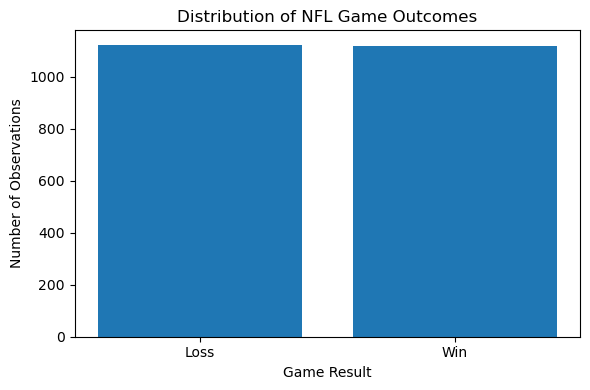

In [21]:
print(model_data["win"].value_counts())

print()

print(
    model_data["win"]
    .value_counts(normalize=True)
    .round(3)
)

win_counts = model_data["win"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Loss", "Win"],
    win_counts.values
)

plt.title("Distribution of NFL Game Outcomes")
plt.xlabel("Game Result")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

In [22]:
display(
    model_data[features + ["win"]]
    .describe()
    .round(2)
)

,previous_win_pct,last_3_win_pct,points_scored_avg,points_allowed_avg,passing_yards_avg,rushing_yards_avg,turnovers_avg,takeaways_avg,turnover_diff_avg,opponent_win_pct,opponent_points_allowed_avg,home,win
count,2238.00,2238.00,2238.00,2238.00,2238.00,2238.00,2238.00,2238.00,2238.00,2238.00,2238.00,2238.0,2238.0
mean,0.50,0.50,22.52,22.52,237.87,115.76,1.26,1.26,-0.00,0.50,22.52,0.5,0.5
std,0.22,0.32,4.73,4.06,35.40,25.09,0.41,0.47,0.67,0.22,4.06,0.5,0.5
min,0.00,0.00,6.67,8.67,99.00,49.00,0.00,0.00,-2.67,0.00,8.67,0.0,0.0
25%,0.33,0.33,19.00,19.93,213.00,97.95,1.00,1.00,-0.43,0.33,19.93,0.0,0.0
50%,0.50,0.33,22.33,22.50,238.11,113.84,1.25,1.20,0.00,0.50,22.50,0.5,0.0
75%,0.67,0.67,25.71,25.00,260.00,129.15,1.50,1.55,0.42,0.67,25.00,1.0,1.0
max,1.00,1.00,43.33,40.67,401.00,220.25,3.00,3.25,2.33,1.00,40.67,1.0,1.0


In [23]:
comparison = (
    model_data
    .groupby("win")[features]
    .mean()
    .T
)

comparison.columns = [
    "Loss",
    "Win"
]

display(comparison.round(2))

,Loss,Win
previous_win_pct,0.46,0.54
last_3_win_pct,0.44,0.55
points_scored_avg,21.65,23.39
points_allowed_avg,22.94,22.09
passing_yards_avg,232.67,243.09
rushing_yards_avg,113.87,117.67
turnovers_avg,1.27,1.25
takeaways_avg,1.20,1.31
turnover_diff_avg,-0.06,0.06
opponent_win_pct,0.54,0.46


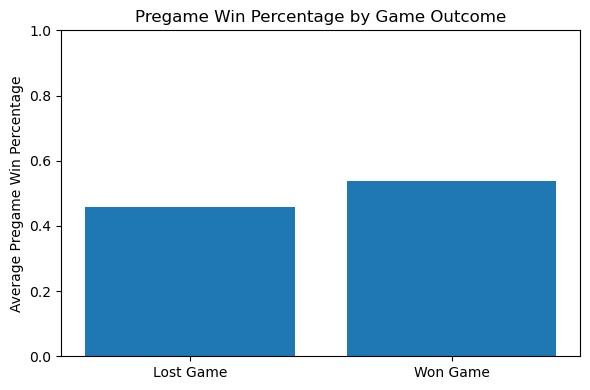

In [24]:
win_pct_comparison = (
    model_data
    .groupby("win")["previous_win_pct"]
    .mean()
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Lost Game", "Won Game"],
    win_pct_comparison.values
)

plt.ylabel("Average Pregame Win Percentage")
plt.title("Pregame Win Percentage by Game Outcome")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

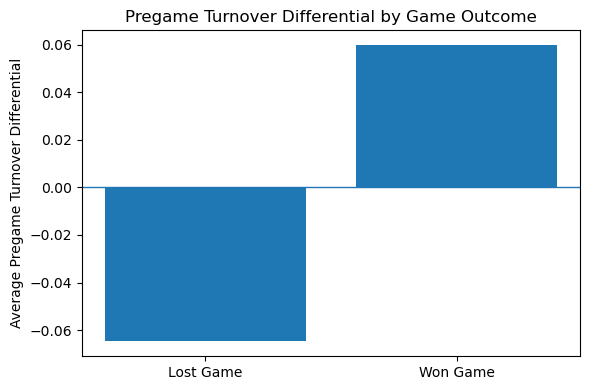

In [25]:
turnover_comparison = (
    model_data
    .groupby("win")["turnover_diff_avg"]
    .mean()
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Lost Game", "Won Game"],
    turnover_comparison.values
)

plt.ylabel("Average Pregame Turnover Differential")
plt.title("Pregame Turnover Differential by Game Outcome")

plt.axhline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

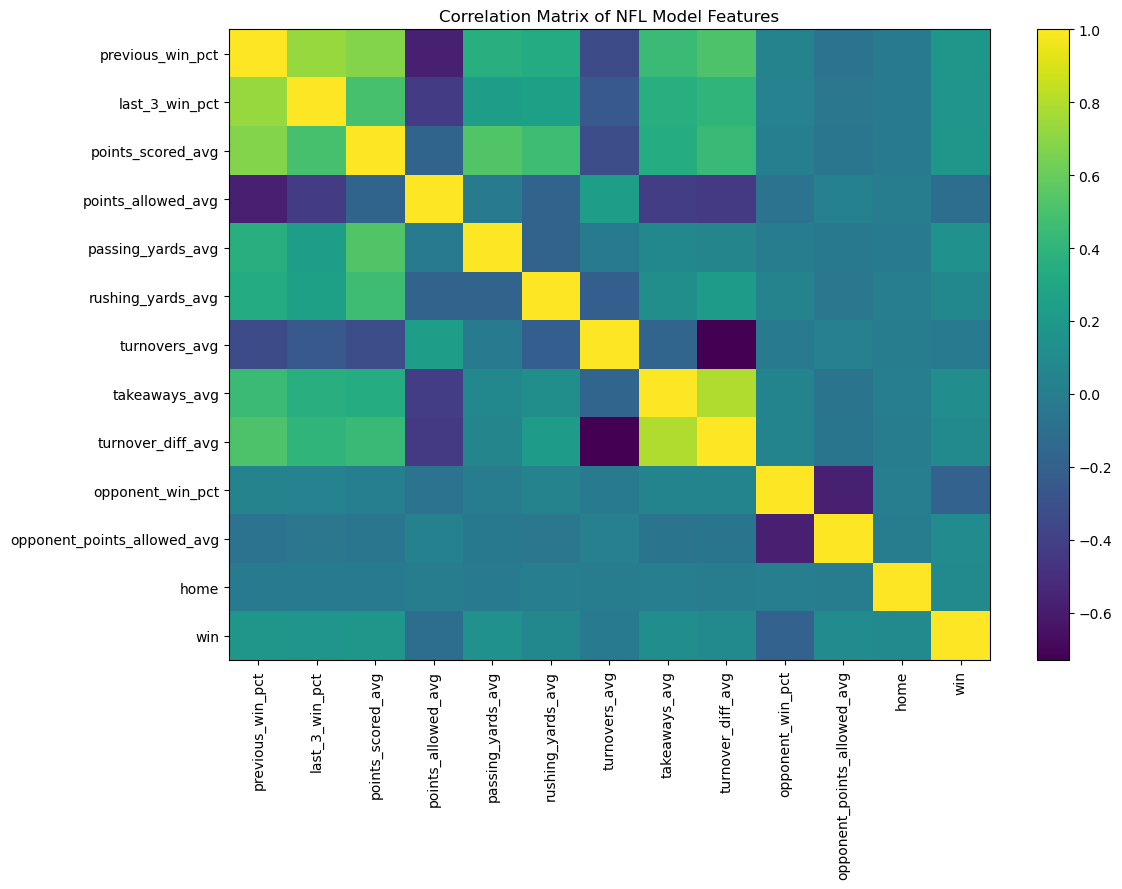

In [26]:
correlation = model_data[
    features + ["win"]
].corr()

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of NFL Model Features")

plt.tight_layout()
plt.show()

In [27]:
final_features = [
    "previous_win_pct",
    "last_3_win_pct",
    "points_scored_avg",
    "points_allowed_avg",
    "passing_yards_avg",
    "rushing_yards_avg",
    "turnover_diff_avg",
    "opponent_win_pct",
    "opponent_points_allowed_avg",
    "home"
]

In [28]:
train = model_data[
    model_data["season"] < 2025
].copy()

test = model_data[
    model_data["season"] == 2025
].copy()

X_train = train[final_features]
y_train = train["win"]

X_test = test[final_features]
y_test = test["win"]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print()
print("Training seasons:")
print(train["season"].value_counts().sort_index())

print()
print("Testing seasons:")
print(test["season"].value_counts().sort_index())

Training observations: 1790
Testing observations: 448

Training seasons:
season
2021    448
2022    446
2023    448
2024    448
Name: count, dtype: int64

Testing seasons:
season
2025    448
Name: count, dtype: int64


In [29]:
print("Observations after cleaning:", len(model_data))

print(model_data["win"].value_counts())

print("Training:", len(X_train))
print("Testing:", len(X_test))

Observations after cleaning: 2238
win
0    1122
1    1116
Name: count, dtype: int64
Training: 1790
Testing: 448


In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print(
    "Baseline Accuracy:",
    round(accuracy_score(y_test, baseline_predictions), 3)
)

Baseline Accuracy: 0.502


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print(
    "Accuracy:",
    round(accuracy_score(y_test, rf_predictions), 3)
)

print(
    "Precision:",
    round(precision_score(y_test, rf_predictions), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, rf_predictions), 3)
)

print(
    "F1 Score:",
    round(f1_score(y_test, rf_predictions), 3)
)

Accuracy: 0.625
Precision: 0.626
Recall: 0.614
F1 Score: 0.62


In [33]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_predictions),
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions)
    ],

    "Precision": [
        precision_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            log_predictions
        ),
        precision_score(
            y_test,
            rf_predictions
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            log_predictions
        ),
        recall_score(
            y_test,
            rf_predictions
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            log_predictions
        ),
        f1_score(
            y_test,
            rf_predictions
        )
    ]
})

display(results.round(3))

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.502,0.000,0.000,0.000
1,Logistic Regression,0.621,0.627,0.587,0.606
2,Random Forest,0.625,0.626,0.614,0.620


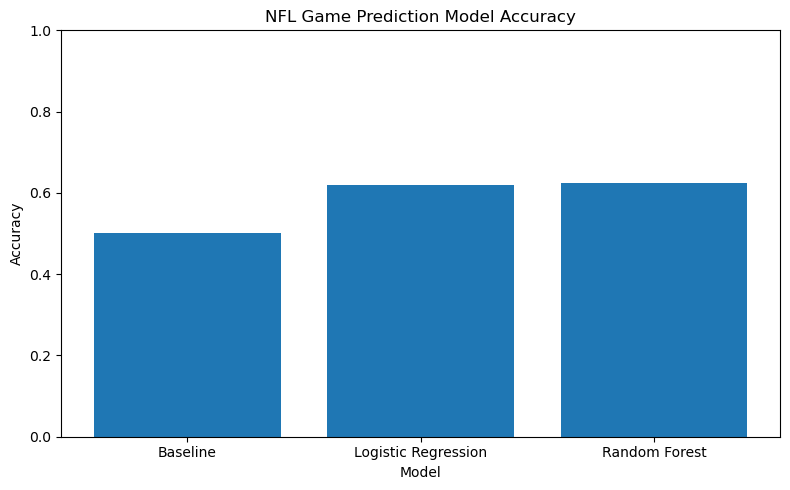

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.title(
    "NFL Game Prediction Model Accuracy"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

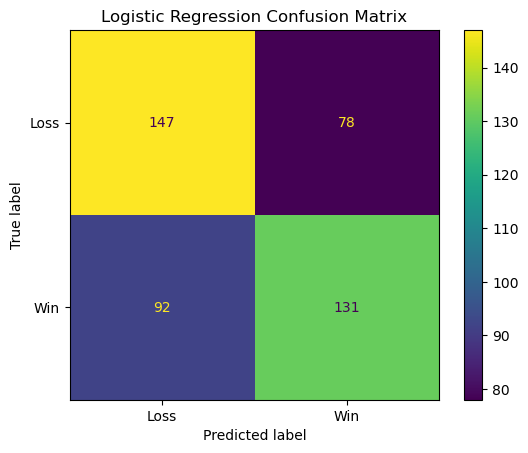

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_predictions,
    display_labels=["Loss", "Win"]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

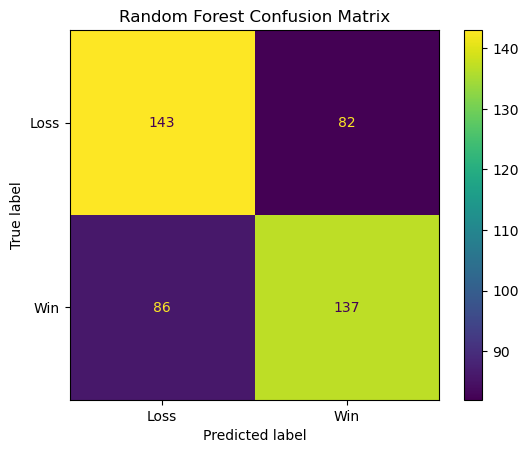

In [36]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["Loss", "Win"]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [37]:
importance = pd.DataFrame({
    "Feature": final_features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance.round(3))

,Feature,Importance
2,points_scored_avg,0.143
4,passing_yards_avg,0.129
7,opponent_win_pct,0.122
3,points_allowed_avg,0.119
5,rushing_yards_avg,0.117
8,opponent_points_allowed_avg,0.114
6,turnover_diff_avg,0.103
0,previous_win_pct,0.097
1,last_3_win_pct,0.033
9,home,0.022


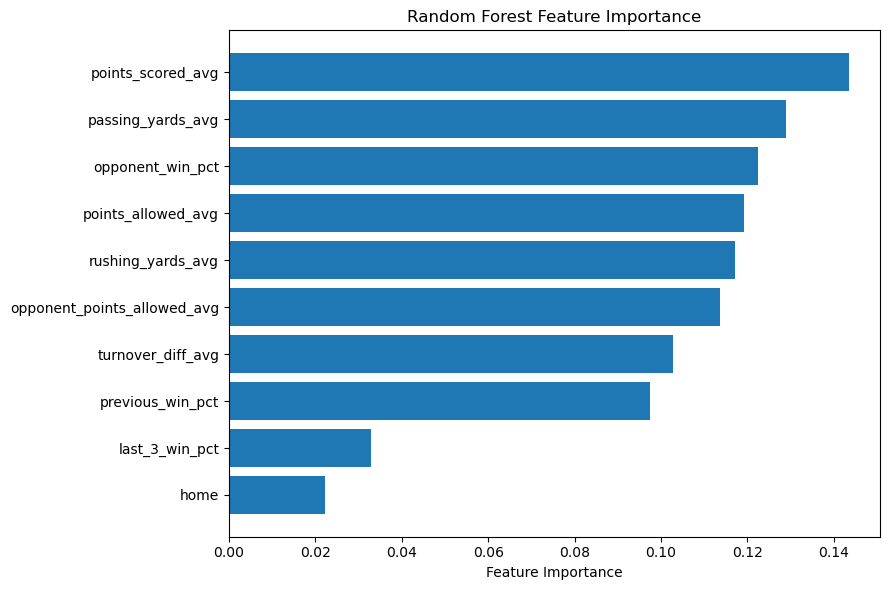

In [38]:
plot_importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance"]
)

plt.xlabel("Feature Importance")

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()
plt.show()

In [39]:
logistic = log_model.named_steps[
    "logisticregression"
]

coefficients = pd.DataFrame({
    "Feature": final_features,
    "Coefficient": logistic.coef_[0]
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

display(coefficients.round(3))

,Feature,Coefficient
4,passing_yards_avg,0.239
9,home,0.231
1,last_3_win_pct,0.154
2,points_scored_avg,0.136
5,rushing_yards_avg,0.109
0,previous_win_pct,0.028
6,turnover_diff_avg,0.024
8,opponent_points_allowed_avg,-0.050
3,points_allowed_avg,-0.081
7,opponent_win_pct,-0.445


In [40]:
predictions = test[
    [
        "season",
        "week",
        "team",
        "opponent",
        "win"
    ]
].copy()

predictions["logistic_prediction"] = log_predictions
predictions["random_forest_prediction"] = rf_predictions

display(predictions.head(20))

,season,week,team,opponent,win,logistic_prediction,random_forest_prediction
2177,2025,4,ARI,SEA,0,0,1
2178,2025,5,ARI,TEN,0,1,1
2179,2025,6,ARI,IND,0,0,0
2180,2025,7,ARI,GB,0,0,0
2181,2025,9,ARI,DAL,1,0,0
2182,2025,10,ARI,SEA,0,0,0
2183,2025,11,ARI,SF,0,0,0
2184,2025,12,ARI,JAX,0,0,0
2185,2025,13,ARI,TB,0,0,0
2186,2025,14,ARI,LA,0,0,0


In [41]:
predictions["actual_result"] = predictions["win"].map({
    0: "Loss",
    1: "Win"
})

predictions["logistic_result"] = predictions[
    "logistic_prediction"
].map({
    0: "Loss",
    1: "Win"
})

predictions["random_forest_result"] = predictions[
    "random_forest_prediction"
].map({
    0: "Loss",
    1: "Win"
})

display(
    predictions[
        [
            "week",
            "team",
            "opponent",
            "actual_result",
            "logistic_result",
            "random_forest_result"
        ]
    ].head(20)
)

,week,team,opponent,actual_result,logistic_result,random_forest_result
2177,4,ARI,SEA,Loss,Loss,Win
2178,5,ARI,TEN,Loss,Win,Win
2179,6,ARI,IND,Loss,Loss,Loss
2180,7,ARI,GB,Loss,Loss,Loss
2181,9,ARI,DAL,Win,Loss,Loss
2182,10,ARI,SEA,Loss,Loss,Loss
2183,11,ARI,SF,Loss,Loss,Loss
2184,12,ARI,JAX,Loss,Loss,Loss
2185,13,ARI,TB,Loss,Loss,Loss
2186,14,ARI,LA,Loss,Loss,Loss


In [42]:
predictions = test[
    [
        "season",
        "week",
        "team",
        "opponent",
        "win"
    ]
].copy()

predictions["logistic_prediction"] = log_predictions
predictions["rf_prediction"] = rf_predictions

predictions["logistic_win_probability"] = (
    log_model.predict_proba(X_test)[:, 1]
)

predictions["rf_win_probability"] = (
    rf_model.predict_proba(X_test)[:, 1]
)

display(predictions.head(20))

,season,week,team,opponent,win,logistic_prediction,rf_prediction,logistic_win_probability,rf_win_probability
2177,2025,4,ARI,SEA,0,0,1,0.433938,0.515
2178,2025,5,ARI,TEN,0,1,1,0.673046,0.615
2179,2025,6,ARI,IND,0,0,0,0.204725,0.115
2180,2025,7,ARI,GB,0,0,0,0.399008,0.295
2181,2025,9,ARI,DAL,1,0,0,0.375395,0.400
2182,2025,10,ARI,SEA,0,0,0,0.292942,0.265
2183,2025,11,ARI,SF,0,0,0,0.454012,0.265
2184,2025,12,ARI,JAX,0,0,0,0.470387,0.355
2185,2025,13,ARI,TB,0,0,0,0.345168,0.405
2186,2025,14,ARI,LA,0,0,0,0.378716,0.295


In [43]:
from sklearn.metrics import accuracy_score
import pandas as pd

validation_results = []

# Validate using 2022, 2023, and 2024
for test_season in [2022, 2023, 2024]:

    # Train using seasons before the validation season
    train_cv = model_data[
        model_data["season"] < test_season
    ]

    # Validate using the next season
    test_cv = model_data[
        model_data["season"] == test_season
    ]

    X_train_cv = train_cv[final_features]
    y_train_cv = train_cv["win"]

    X_test_cv = test_cv[final_features]
    y_test_cv = test_cv["win"]

    # Logistic Regression
    log_model.fit(X_train_cv, y_train_cv)

    log_predictions_cv = log_model.predict(X_test_cv)

    log_accuracy = accuracy_score(
        y_test_cv,
        log_predictions_cv
    )

    # Random Forest
    rf_model.fit(X_train_cv, y_train_cv)

    rf_predictions_cv = rf_model.predict(X_test_cv)

    rf_accuracy = accuracy_score(
        y_test_cv,
        rf_predictions_cv
    )

    validation_results.append({
        "Season": test_season,
        "Logistic Regression": log_accuracy,
        "Random Forest": rf_accuracy
    })

cv_results = pd.DataFrame(validation_results)

display(cv_results.round(3))

,Season,Logistic Regression,Random Forest
0,2022,0.617,0.531
1,2023,0.587,0.589
2,2024,0.690,0.636


In [ ]:
print("Logistic Regression Average:", round(cv_results["Logistic Regression"].mean(), 3))

print("Random Forest Average:", round(cv_results["Random Forest"].mean(), 3))

print("Logistic Regression Standard Deviation:", round(cv_results["Logistic Regression"].std(), 3))

print("Random Forest Standard Deviation:", round(cv_results["Random Forest"].std(), 3))

Logistic Regression Average: 0.631
Random Forest Average: 0.586
Logistic Regression Standard Deviation: 0.053
Random Forest Standard Deviation: 0.052


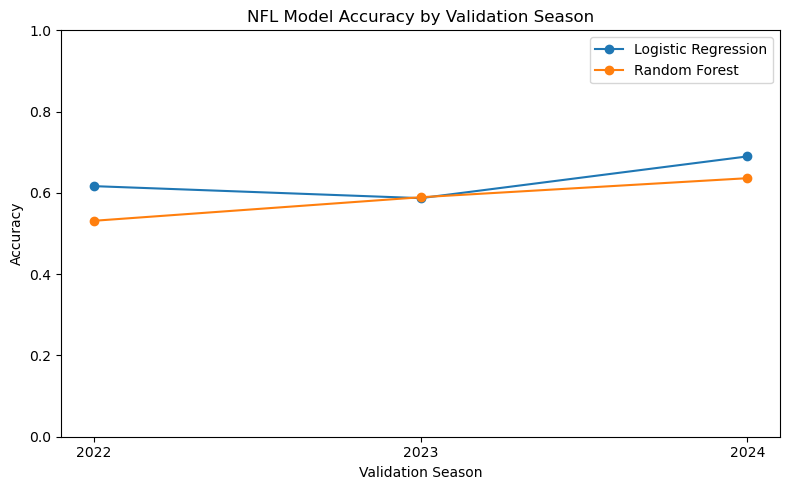

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    cv_results["Season"],
    cv_results["Logistic Regression"],
    marker="o", label="Logistic Regression")

plt.plot(
    cv_results["Season"],
    cv_results["Random Forest"],
    marker="o", label="Random Forest")

plt.xlabel("Validation Season")
plt.ylabel("Accuracy")

plt.title("NFL Model Accuracy by Validation Season")

plt.xticks([2022, 2023, 2024])

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()
plt.show()

In [46]:
train = model_data[model_data["season"] < 2025].copy()
test = model_data[model_data["season"] == 2025].copy()

X_train = train[final_features]
y_train = train["win"]

X_test = test[final_features]
y_test = test["win"]

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)
log_probabilities = log_model.predict_proba(X_test)[:, 1]

In [47]:
error_analysis = test[
    [
        "season",
        "week",
        "team",
        "opponent",
        "win"
    ]
].copy()

error_analysis["prediction"] = log_predictions

error_analysis["win_probability"] = log_probabilities

error_analysis["correct"] = (
    error_analysis["win"] ==
    error_analysis["prediction"]
)

In [ ]:
print(error_analysis["correct"].value_counts())

correct
True     278
False    170
Name: count, dtype: int64


In [49]:
mistakes = error_analysis[error_analysis["correct"] == False].copy()

display(mistakes.head(20))

,season,week,team,opponent,win,prediction,win_probability,correct
2178,2025,5,ARI,TEN,0,1,0.673046,False
2181,2025,9,ARI,DAL,1,0,0.375395,False
2188,2025,16,ARI,ATL,0,1,0.534205,False
2194,2025,4,ATL,WAS,1,0,0.389094,False
2195,2025,6,ATL,BUF,1,0,0.417735,False
2197,2025,8,ATL,MIA,0,1,0.730366,False
2201,2025,12,ATL,NO,1,0,0.472841,False
2202,2025,13,ATL,NYJ,0,1,0.526816,False
2204,2025,15,ATL,TB,1,0,0.333991,False
2206,2025,17,ATL,LA,1,0,0.424360,False


In [50]:
mistakes["actual_result"] = mistakes["win"].map({0: "Loss", 1: "Win"})

mistakes["predicted_result"] = mistakes["prediction"].map({0: "Loss", 1: "Win"})

display(
    mistakes[
        [
            "week",
            "team",
            "opponent",
            "actual_result",
            "predicted_result",
            "win_probability"
        ]
    ].head(20)
)

,week,team,opponent,actual_result,predicted_result,win_probability
2178,5,ARI,TEN,Loss,Win,0.673046
2181,9,ARI,DAL,Win,Loss,0.375395
2188,16,ARI,ATL,Loss,Win,0.534205
2194,4,ATL,WAS,Win,Loss,0.389094
2195,6,ATL,BUF,Win,Loss,0.417735
2197,8,ATL,MIA,Loss,Win,0.730366
2201,12,ATL,NO,Win,Loss,0.472841
2202,13,ATL,NYJ,Loss,Win,0.526816
2204,15,ATL,TB,Win,Loss,0.333991
2206,17,ATL,LA,Win,Loss,0.424360


In [52]:
mistakes["confidence"] = (mistakes["win_probability"] - 0.5).abs()

biggest_mistakes = mistakes.sort_values("confidence",ascending=False)

display(
    biggest_mistakes[
        [
            "week",
            "team",
            "opponent",
            "actual_result",
            "predicted_result",
            "win_probability"
        ]
    ].head(15)
)

,week,team,opponent,actual_result,predicted_result,win_probability
2688,5,TEN,ARI,Win,Loss,0.165072
2282,7,CIN,PIT,Win,Loss,0.175578
2466,4,LAC,NYG,Loss,Win,0.802230
2602,4,PHI,TB,Win,Loss,0.209437
2568,4,NYG,LAC,Win,Loss,0.215349
2331,5,DEN,PHI,Win,Loss,0.219721
2557,10,NO,CAR,Win,Loss,0.220845
2229,5,BUF,NE,Loss,Win,0.759725
2589,8,NYJ,CIN,Win,Loss,0.246716
2535,5,NE,BUF,Win,Loss,0.247013


In [53]:
correct = error_analysis["correct"].sum()
incorrect = (~error_analysis["correct"]).sum()

print("Correct predictions:", correct)
print("Incorrect predictions:", incorrect)

print(
    "Error rate:",
    round(incorrect / len(error_analysis), 3)
)

Correct predictions: 278
Incorrect predictions: 170
Error rate: 0.379
